In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df=pd.read_csv("12-health_risk_classification.csv")

In [4]:
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


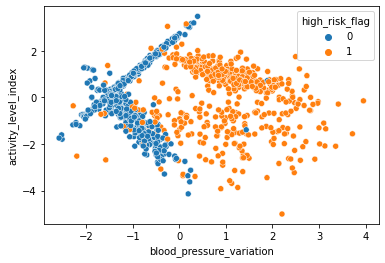

In [6]:
sns.scatterplot(x=df["blood_pressure_variation"],y=df["activity_level_index"],hue=df["high_risk_flag"])
plt.show()

In [8]:
df["high_risk_flag"].value_counts()

0    502
1    498
Name: high_risk_flag, dtype: int64

In [9]:
X=df.drop("high_risk_flag",axis=1)
y=df["high_risk_flag"]

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler=StandardScaler()

In [18]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
classifier=KNeighborsClassifier(n_neighbors=5,algorithm="auto",weights="uniform")

In [25]:
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [26]:
y_pred=classifier.predict(X_test_scaled)

In [27]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [28]:
print("confusion matirx : \n",confusion_matrix(y_test,y_pred))
print("accuracy score : \n",accuracy_score(y_test,y_pred))
print("classification report : \n",classification_report(y_test,y_pred))


confusion matirx : 
 [[124   2]
 [ 10 114]]
accuracy score : 
 0.952
classification report : 
               precision    recall  f1-score   support

           0       0.93      0.98      0.95       126
           1       0.98      0.92      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [29]:
classifier=KNeighborsClassifier(n_neighbors=5,algorithm="kd_tree",weights="uniform")
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(algorithm='kd_tree')

In [30]:
y_pred=classifier.predict(X_test_scaled)

In [31]:
print("confusion matirx : \n",confusion_matrix(y_test,y_pred))
print("accuracy score : \n",accuracy_score(y_test,y_pred))
print("classification report : \n",classification_report(y_test,y_pred))


confusion matirx : 
 [[124   2]
 [ 10 114]]
accuracy score : 
 0.952
classification report : 
               precision    recall  f1-score   support

           0       0.93      0.98      0.95       126
           1       0.98      0.92      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [32]:
classifier=KNeighborsClassifier(n_neighbors=3,algorithm="kd_tree",weights="uniform")
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=3)

In [33]:
y_pred=classifier.predict(X_test_scaled)

In [34]:
print("confusion matirx : \n",confusion_matrix(y_test,y_pred))
print("accuracy score : \n",accuracy_score(y_test,y_pred))
print("classification report : \n",classification_report(y_test,y_pred))


confusion matirx : 
 [[125   1]
 [  9 115]]
accuracy score : 
 0.96
classification report : 
               precision    recall  f1-score   support

           0       0.93      0.99      0.96       126
           1       0.99      0.93      0.96       124

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [35]:
dfreg=pd.read_csv("12-house_energy_regression.csv")

In [36]:
dfreg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


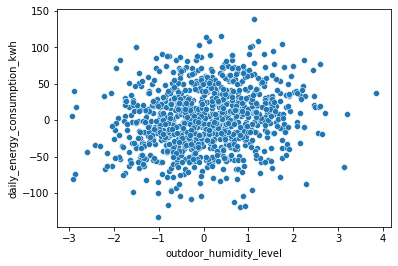

In [38]:
sns.scatterplot(x=dfreg["outdoor_humidity_level"],y=dfreg["daily_energy_consumption_kwh"])
plt.show()

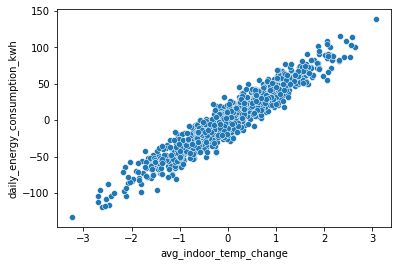

In [39]:
sns.scatterplot(x=dfreg["avg_indoor_temp_change"],y=dfreg["daily_energy_consumption_kwh"])
plt.show()

In [40]:
dfreg.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


In [42]:
X=dfreg.drop("daily_energy_consumption_kwh",axis=1)
y=dfreg["daily_energy_consumption_kwh"]

In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [45]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [46]:
from sklearn.neighbors import KNeighborsRegressor

In [47]:
regressor=KNeighborsRegressor(n_neighbors=5,algorithm="auto")

In [48]:
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor()

In [49]:
y_pred=regressor.predict(X_test_scaled)

In [50]:
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [51]:
print("r2 score",r2_score(y_test,y_pred))
print("mean absolute error",mean_absolute_error(y_test,y_pred))
print("mean squared error",mean_squared_error(y_test,y_pred))


r2 score 0.9183109118983248
mean absolute error 9.228754406902722
mean squared error 135.6610827281179


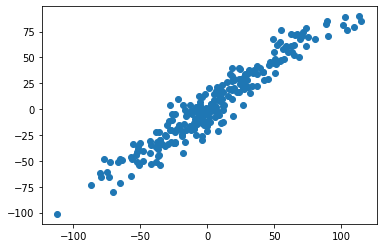

In [52]:
plt.scatter(y_test,y_pred)
plt.show()

In [53]:
regressor=KNeighborsRegressor(n_neighbors=7)

In [54]:
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor(n_neighbors=7)

In [55]:
y_pred=regressor.predict(X_test_scaled)

In [56]:
print("r2 score",r2_score(y_test,y_pred))
print("mean absolute error",mean_absolute_error(y_test,y_pred))
print("mean squared error",mean_squared_error(y_test,y_pred))


r2 score 0.9189374253850693
mean absolute error 9.326118628600977
mean squared error 134.62063167240598
